In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

def load_img(path_to_img):
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def tensor_to_image(tensor):
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

In [ ]:
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

In [ ]:
content_path = 'Знаменитость.jpg'
style_art_path = 'Арт.jpg'
style_cartoon_path = 'Мультфильм2.jpg'

content_image = load_img(content_path)
style_art = load_img(style_art_path)
style_cartoon = load_img(style_cartoon_path)

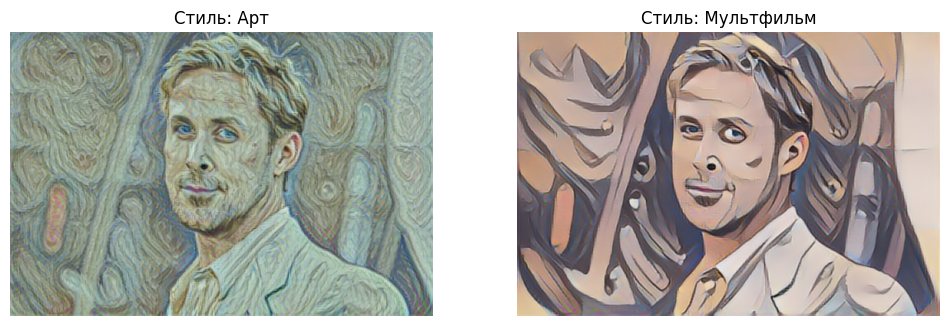

In [ ]:
stylized_art = hub_model(tf.constant(content_image), tf.constant(style_art))[0]
stylized_cartoon = hub_model(tf.constant(content_image), tf.constant(style_cartoon))[0]

img_art = tensor_to_image(stylized_art)
img_cartoon = tensor_to_image(stylized_cartoon)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_art)
plt.title('Стиль: Арт')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_cartoon)
plt.title('Стиль: Мультфильм')
plt.axis('off')
plt.show()

img_art.save('result_art.jpg')
img_cartoon.save('result_cartoon.jpg')


In [ ]:
sed -i "s/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/" /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
%cd /content/
!rm -rf Real-ESRGAN
!python inference_realesrgan.py -n RealESRGAN_x4plus -i /content/Качество2.jpg --outscale 4 --face_enhance
!git clone https://github.com/xinntao/Real-ESRGAN.git

%cd /content/Real-ESRGAN
!pip install basicsr facexlib gfpgan -q
!pip install -r requirements.txt -q
!python setup.py develop -q

!mkdir -p weights
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth -P weights/


/content
python3: can't open file '/content/inference_realesrgan.py': [Errno 2] No such file or directory
Cloning into 'Real-ESRGAN'...
remote: Enumerating objects: 759, done.
remote: Total 759 (delta 0), reused 0 (delta 0), pack-reused 759 (from 1)
Receiving objects: 100% (759/759), 5.39 MiB | 10.29 MiB/s, done.
Resolving deltas: 100% (408/408), done.
/content/Real-ESRGAN
/usr/local/lib/python3.12/dist-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecatio

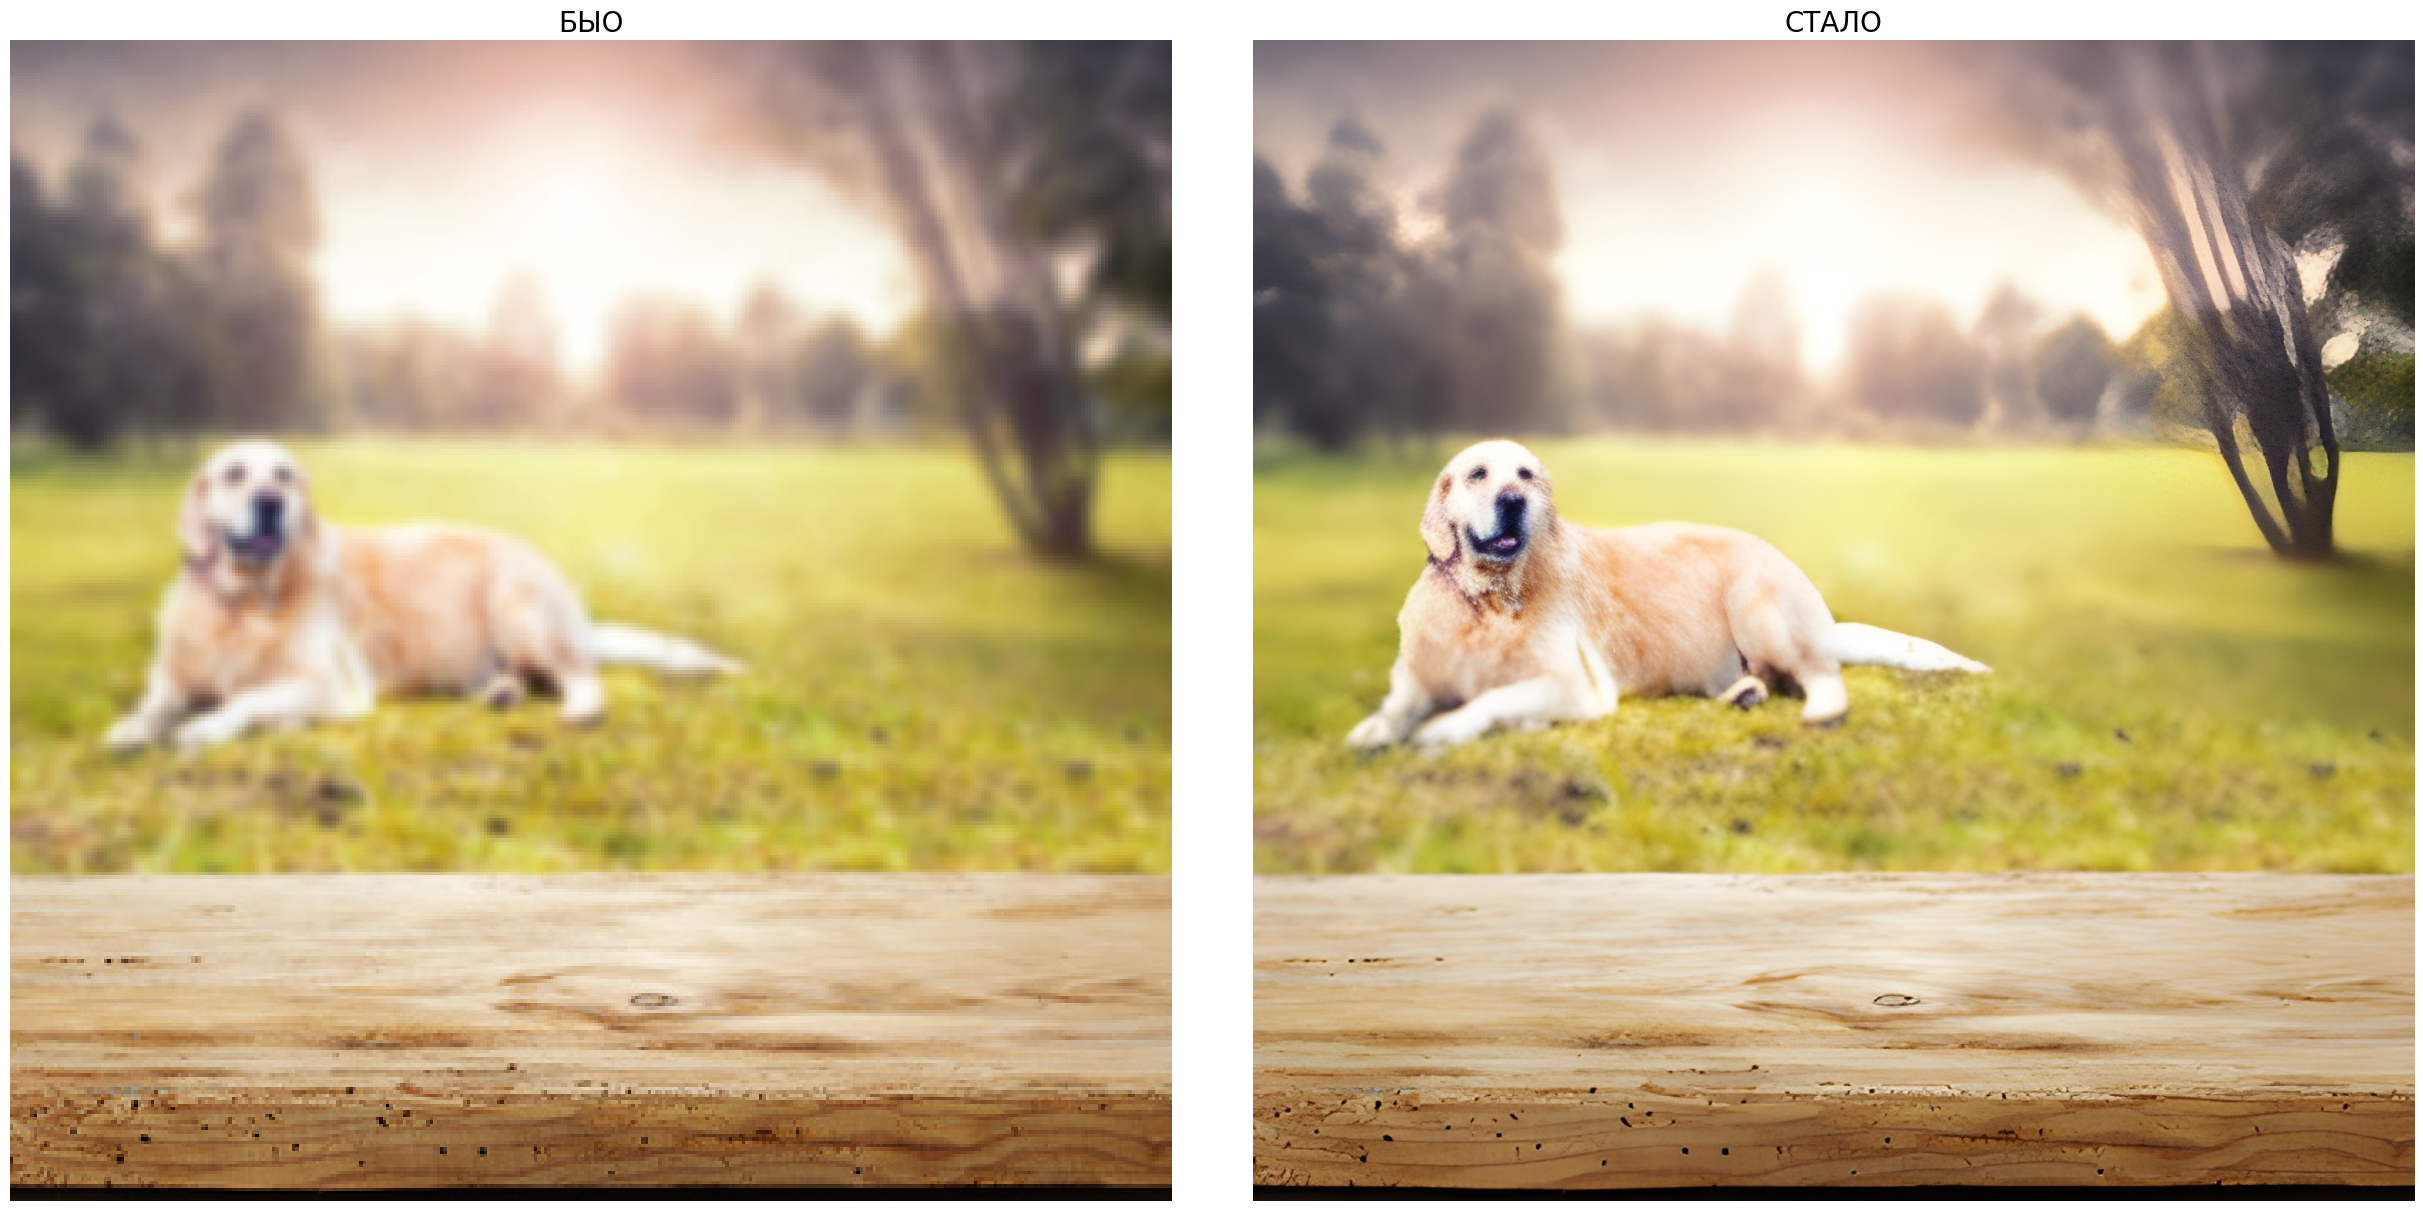

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

orig_path = '/content/Качество2.jpg'
res_path = '/content/Real-ESRGAN/results/Качество2_out.jpg'

if os.path.exists(res_path):
    img_orig = cv2.imread(orig_path)
    img_res = cv2.imread(res_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_res = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(25, 12))
    plt.subplot(1, 2, 1)
    plt.title('БЫО', fontsize=20)
    plt.imshow(img_orig)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('СТАЛО', fontsize=20)
    plt.imshow(img_res)
    plt.axis('off')

    plt.tight_layout()
    plt.show()